In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT = Path(".").resolve()
EXPS = ["centralized", "fedavg", "bank_perclient"]
# Non-gsm8k evals (A40 runs skip gsm8k)
BENCHES = ["hellaswag", "xsum", "hotpotqa", "mbpp"]


<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
BASE_5 = ROOT / "5multiconfig" / "results"
BASE_2 = ROOT / "2multiconfig" / "results"
RUN_TAGS_5 = ["ta_rho05", "ta_rho0", "ta_rglobal2", "ta_participation_mid", "ta_beta50"]
RUN_TAGS_2 = ["ta_mid_shared_strong", "ta_low_shared_weighted"]

def _latest_run(base, prefix):
    if not base.exists():
        return None
    runs = sorted([p for p in base.iterdir() if p.is_dir() and p.name.startswith(prefix)], key=lambda p: p.stat().st_mtime)
    return runs[-1].name if runs else None

RUN_ID_5 = _latest_run(BASE_5, "5multiconfig_taskaware_")
RUN_ID_2 = _latest_run(BASE_2, "2run_taskaware_")

RUNS = []
if RUN_ID_5:
    RUNS += [
        {"label": f"{RUN_ID_5}/{tag}", "root": str(BASE_5 / RUN_ID_5 / tag)}
        for tag in RUN_TAGS_5
    ]
if RUN_ID_2:
    RUNS += [
        {"label": f"{RUN_ID_2}/{tag}", "root": str(BASE_2 / RUN_ID_2 / tag)}
        for tag in RUN_TAGS_2
    ]

print(f"Loaded {len(RUNS)} runs: 5multiconfig={RUN_ID_5}, 2multiconfig={RUN_ID_2}")


Loaded 7 runs: 5multiconfig=5multiconfig_taskaware_20260125_194007_27494, 2multiconfig=2run_taskaware_20260127_021653_6243


In [3]:
def _find_accuracy_file(run_root, exp, bench):
    base = run_root / "global" / exp / bench
    if not base.exists():
        return None
    candidates = list(base.glob(f"**/eval_result/accuracies_*__{bench}.json"))
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime)
    return candidates[-1]

def _parse_metric(bench, data):
    if bench in {"gsm8k", "hellaswag", "piqa"}:
        val = data.get("weighted_accuracy")
        if val is None and bench == "gsm8k":
            val = data.get("categories", {}).get("gsm8k")
        return "weighted_accuracy", val
    if bench == "xsum":
        return "rougeL_f1", data.get("rougeL_f1")
    if bench == "hotpotqa":
        return "f1", data.get("f1")
    if bench in {"mbpp", "apps"}:
        return "pass@1", data.get("pass@1")
    if bench == "toolbench":
        val = data.get("score")
        if val is None:
            for key in ("overall", "overall_score", "success_rate"):
                if key in data:
                    val = data[key]
                    break
        return "score", val
    return None, None

def collect_results_df(run_label, run_root):
    rows = []
    for exp in EXPS:
        for bench in BENCHES:
            path = _find_accuracy_file(run_root, exp, bench)
            if path is None:
                rows.append({
                    "run": run_label,
                    "exp": exp,
                    "benchmark": bench,
                    "metric": None,
                    "value": None,
                    "error": "missing",
                    "result_path": None,
                })
                continue
            data = json.loads(path.read_text())
            metric, value = _parse_metric(bench, data)
            rows.append({
                "run": run_label,
                "exp": exp,
                "benchmark": bench,
                "metric": metric,
                "value": value,
                "error": data.get("error"),
                "result_path": str(path),
            })
    return pd.DataFrame(rows)

def plot_run_grid(run_df, run_label, cols=3):
    rows = (len(BENCHES) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 3.6))
    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for idx, bench in enumerate(BENCHES):
        ax = axes[idx]
        subset = run_df[run_df["benchmark"] == bench].copy()
        if subset["value"].notna().sum() == 0:
            ax.set_axis_off()
            continue
        sns.barplot(data=subset, x="exp", y="value", order=EXPS, ax=ax)
        metric = subset["metric"].dropna().iloc[0] if not subset["metric"].dropna().empty else "metric"
        ax.set_title(bench)
        ax.set_xlabel("")
        ax.set_ylabel(metric)
    for j in range(len(BENCHES), len(axes)):
        axes[j].set_axis_off()
    fig.suptitle(run_label, fontsize=12)
    fig.tight_layout()
    plt.show()


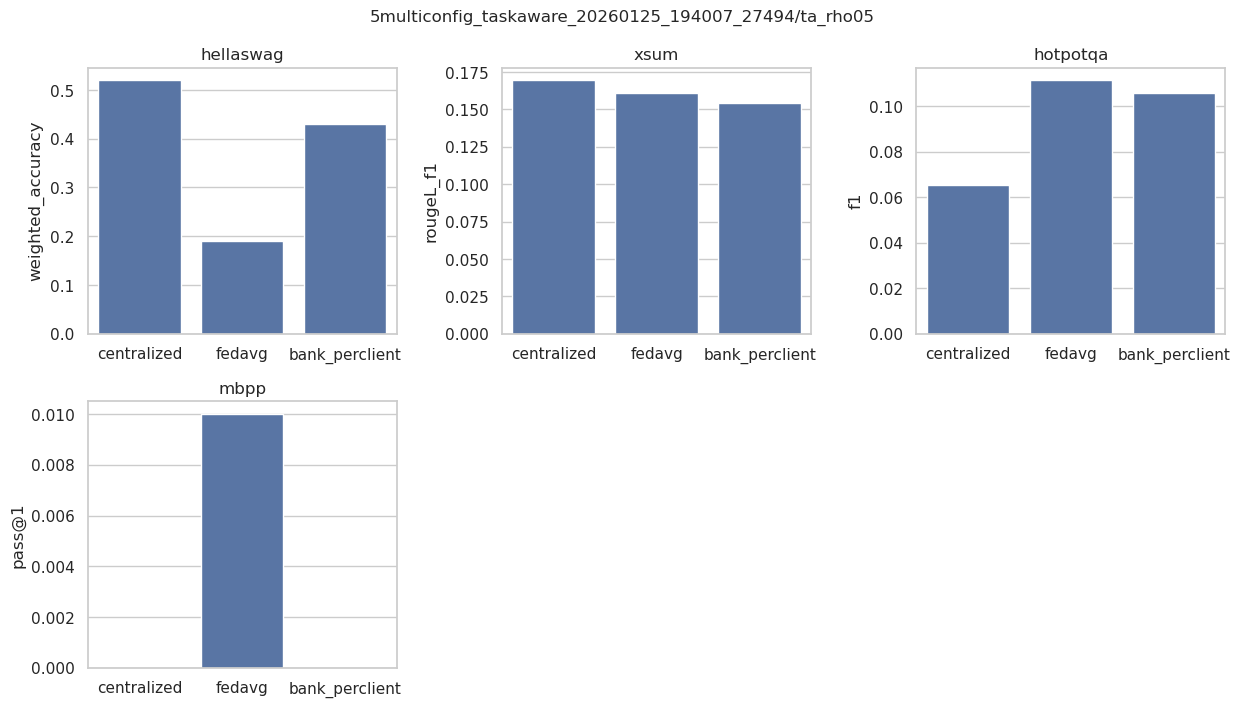

,run,exp,benchmark,metric,value,error,result_path
8,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,hellaswag,weighted_accuracy,0.430000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
0,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hellaswag,weighted_accuracy,0.520000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
4,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,hellaswag,weighted_accuracy,0.190000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
10,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,hotpotqa,f1,0.105608,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
2,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hotpotqa,f1,0.065522,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
6,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,hotpotqa,f1,0.111323,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
11,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,mbpp,pass@1,0.000000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
3,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,mbpp,pass@1,0.000000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
7,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,mbpp,pass@1,0.010000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
9,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,xsum,rougeL_f1,0.154079,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...


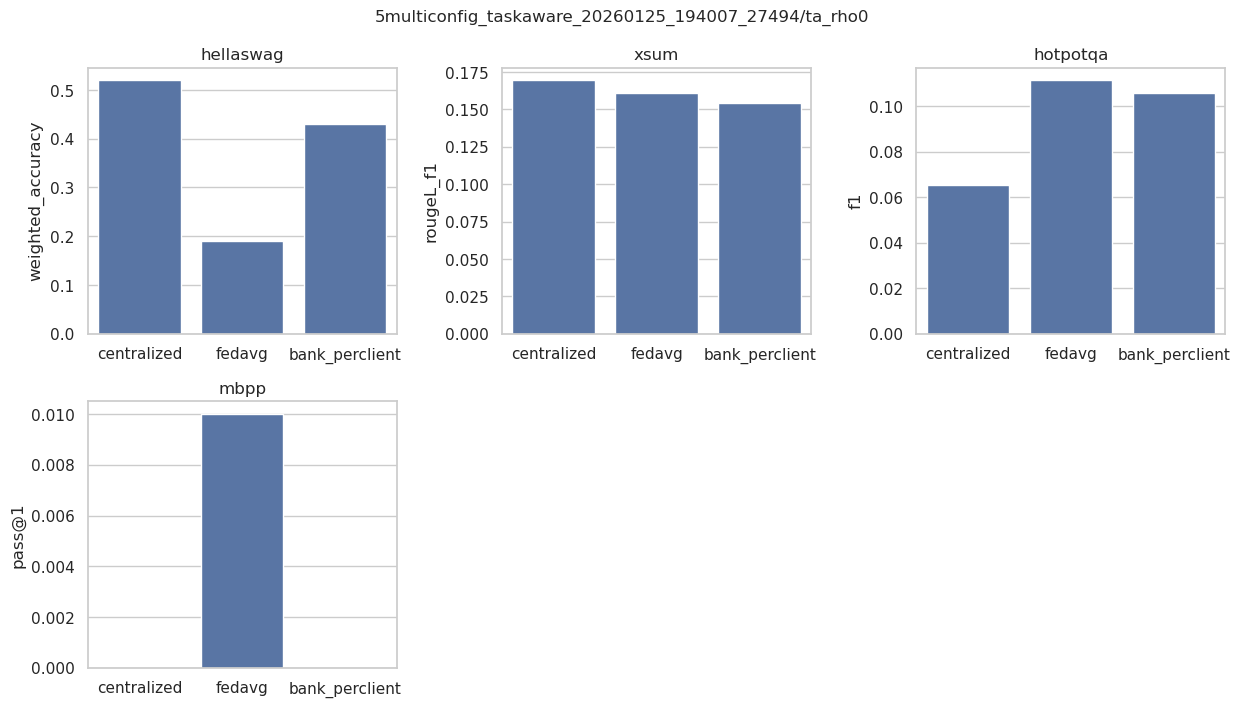

,run,exp,benchmark,metric,value,error,result_path
8,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,hellaswag,weighted_accuracy,0.430000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
0,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hellaswag,weighted_accuracy,0.520000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
4,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,hellaswag,weighted_accuracy,0.190000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
10,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,hotpotqa,f1,0.105608,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
2,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hotpotqa,f1,0.065522,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
6,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,hotpotqa,f1,0.111323,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
11,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,mbpp,pass@1,0.000000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
3,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,mbpp,pass@1,0.000000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
7,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,mbpp,pass@1,0.010000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
9,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,xsum,rougeL_f1,0.154079,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...


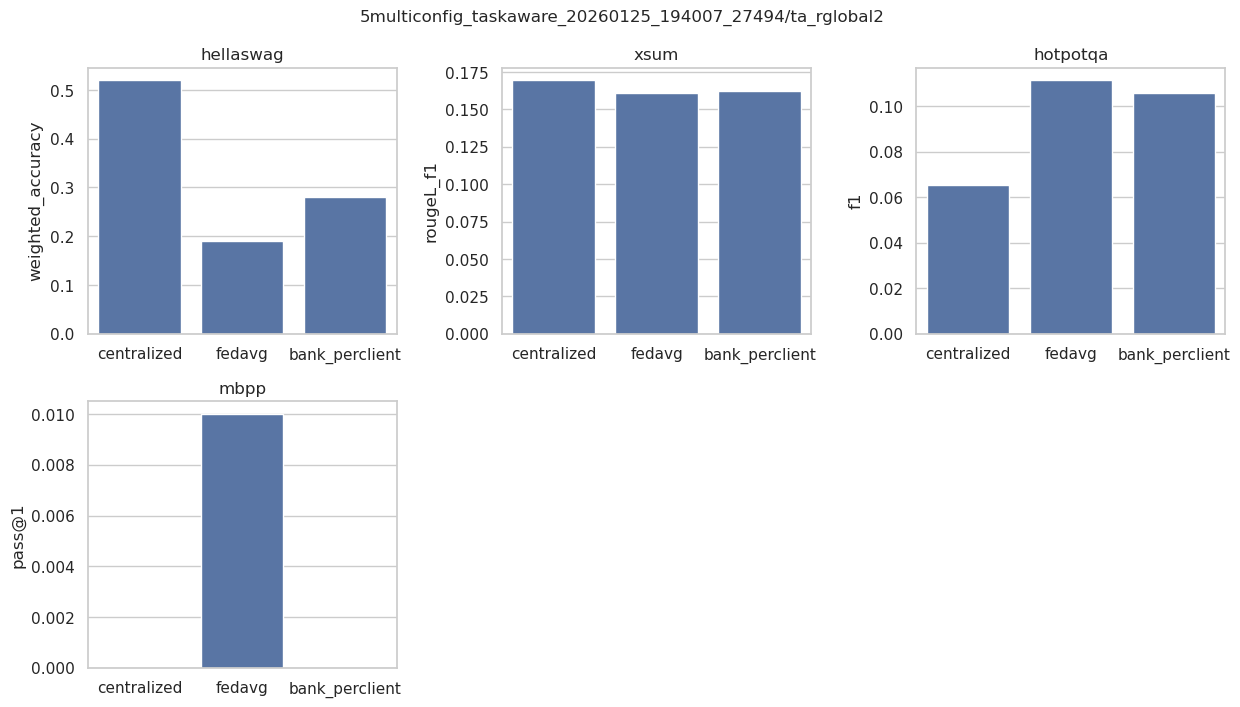

,run,exp,benchmark,metric,value,error,result_path
8,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,hellaswag,weighted_accuracy,0.280000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
0,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hellaswag,weighted_accuracy,0.520000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
4,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,hellaswag,weighted_accuracy,0.190000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
10,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,hotpotqa,f1,0.105564,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
2,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hotpotqa,f1,0.065522,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
6,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,hotpotqa,f1,0.111323,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
11,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,mbpp,pass@1,0.000000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
3,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,mbpp,pass@1,0.000000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
7,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,mbpp,pass@1,0.010000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
9,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,xsum,rougeL_f1,0.162512,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...


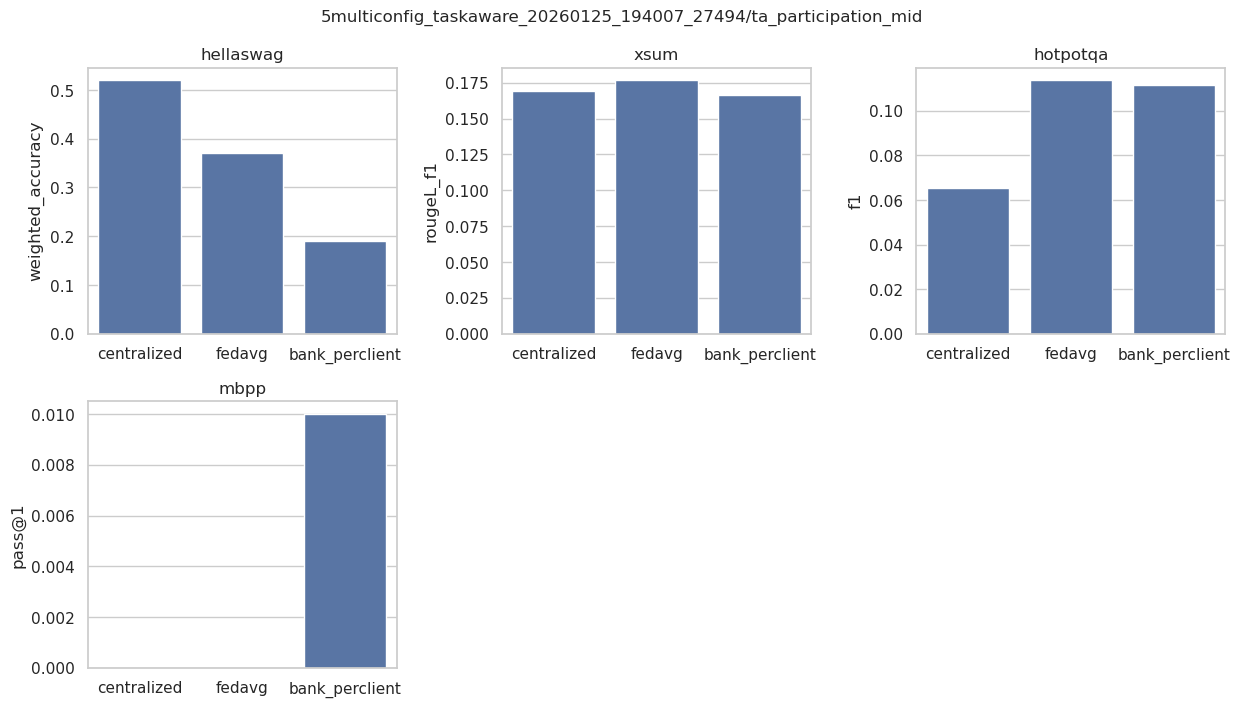

,run,exp,benchmark,metric,value,error,result_path
8,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,hellaswag,weighted_accuracy,0.190000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
0,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hellaswag,weighted_accuracy,0.520000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
4,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,hellaswag,weighted_accuracy,0.370000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
10,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,hotpotqa,f1,0.111603,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
2,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hotpotqa,f1,0.065522,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
6,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,hotpotqa,f1,0.113764,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
11,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,mbpp,pass@1,0.010000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
3,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,mbpp,pass@1,0.000000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
7,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,mbpp,pass@1,0.000000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
9,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,xsum,rougeL_f1,0.166456,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...


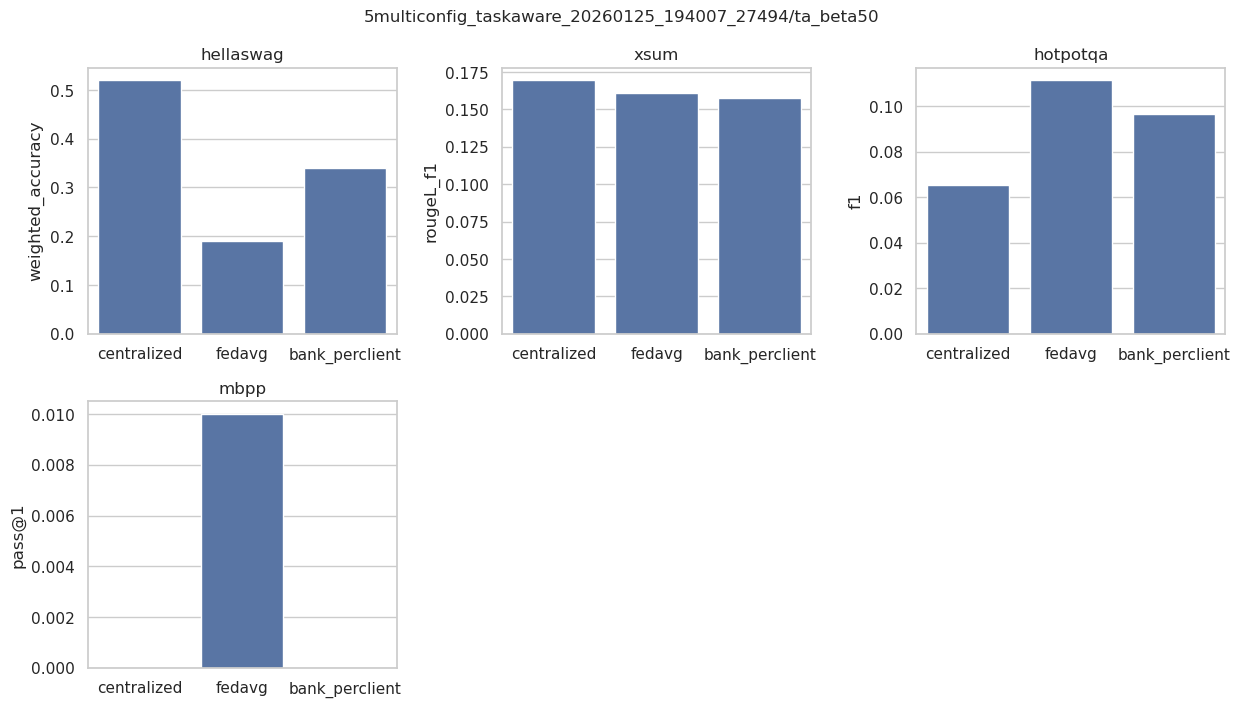

,run,exp,benchmark,metric,value,error,result_path
8,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,hellaswag,weighted_accuracy,0.340000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
0,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hellaswag,weighted_accuracy,0.520000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
4,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,hellaswag,weighted_accuracy,0.190000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
10,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,hotpotqa,f1,0.096271,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
2,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hotpotqa,f1,0.065522,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
6,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,hotpotqa,f1,0.111323,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
11,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,mbpp,pass@1,0.000000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
3,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,mbpp,pass@1,0.000000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
7,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,mbpp,pass@1,0.010000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
9,5multiconfig_taskaware_20260125_194007_27494/t...,bank_perclient,xsum,rougeL_f1,0.157396,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...


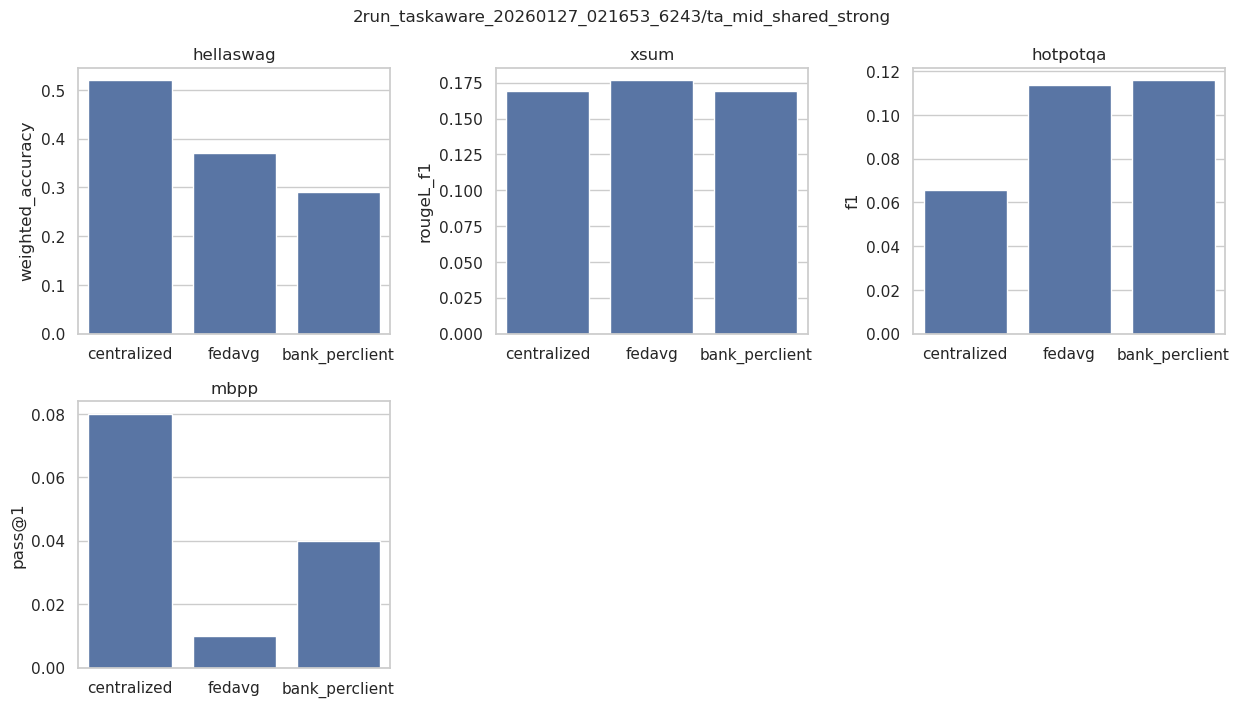

,run,exp,benchmark,metric,value,error,result_path
8,2run_taskaware_20260127_021653_6243/ta_mid_sha...,bank_perclient,hellaswag,weighted_accuracy,0.290000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
0,2run_taskaware_20260127_021653_6243/ta_mid_sha...,centralized,hellaswag,weighted_accuracy,0.520000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
4,2run_taskaware_20260127_021653_6243/ta_mid_sha...,fedavg,hellaswag,weighted_accuracy,0.370000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
10,2run_taskaware_20260127_021653_6243/ta_mid_sha...,bank_perclient,hotpotqa,f1,0.115885,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
2,2run_taskaware_20260127_021653_6243/ta_mid_sha...,centralized,hotpotqa,f1,0.065522,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
6,2run_taskaware_20260127_021653_6243/ta_mid_sha...,fedavg,hotpotqa,f1,0.113764,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
11,2run_taskaware_20260127_021653_6243/ta_mid_sha...,bank_perclient,mbpp,pass@1,0.040000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
3,2run_taskaware_20260127_021653_6243/ta_mid_sha...,centralized,mbpp,pass@1,0.080000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
7,2run_taskaware_20260127_021653_6243/ta_mid_sha...,fedavg,mbpp,pass@1,0.010000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
9,2run_taskaware_20260127_021653_6243/ta_mid_sha...,bank_perclient,xsum,rougeL_f1,0.169510,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...


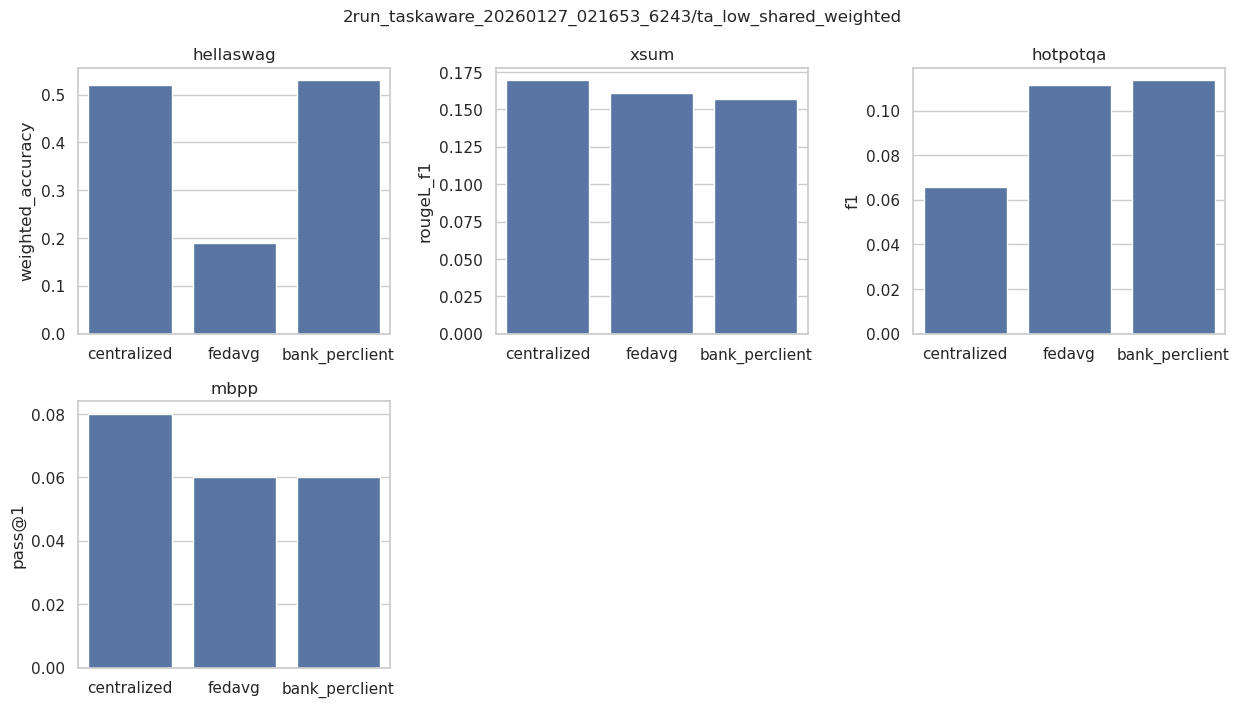

,run,exp,benchmark,metric,value,error,result_path
8,2run_taskaware_20260127_021653_6243/ta_low_sha...,bank_perclient,hellaswag,weighted_accuracy,0.530000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
0,2run_taskaware_20260127_021653_6243/ta_low_sha...,centralized,hellaswag,weighted_accuracy,0.520000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
4,2run_taskaware_20260127_021653_6243/ta_low_sha...,fedavg,hellaswag,weighted_accuracy,0.190000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
10,2run_taskaware_20260127_021653_6243/ta_low_sha...,bank_perclient,hotpotqa,f1,0.113576,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
2,2run_taskaware_20260127_021653_6243/ta_low_sha...,centralized,hotpotqa,f1,0.065522,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
6,2run_taskaware_20260127_021653_6243/ta_low_sha...,fedavg,hotpotqa,f1,0.111323,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
11,2run_taskaware_20260127_021653_6243/ta_low_sha...,bank_perclient,mbpp,pass@1,0.060000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
3,2run_taskaware_20260127_021653_6243/ta_low_sha...,centralized,mbpp,pass@1,0.080000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
7,2run_taskaware_20260127_021653_6243/ta_low_sha...,fedavg,mbpp,pass@1,0.060000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
9,2run_taskaware_20260127_021653_6243/ta_low_sha...,bank_perclient,xsum,rougeL_f1,0.157001,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...


,run,exp,benchmark,metric,value,error,result_path
0,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hellaswag,weighted_accuracy,0.520000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
1,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,xsum,rougeL_f1,0.169568,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
2,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,hotpotqa,f1,0.065522,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
3,5multiconfig_taskaware_20260125_194007_27494/t...,centralized,mbpp,pass@1,0.000000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
4,5multiconfig_taskaware_20260125_194007_27494/t...,fedavg,hellaswag,weighted_accuracy,0.190000,None,/home/heck2/sbhansali8/FTL/5multiconfig/result...
...,...,...,...,...,...,...,...
79,2run_taskaware_20260127_021653_6243/ta_low_sha...,fedavg,mbpp,pass@1,0.060000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
80,2run_taskaware_20260127_021653_6243/ta_low_sha...,bank_perclient,hellaswag,weighted_accuracy,0.530000,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
81,2run_taskaware_20260127_021653_6243/ta_low_sha...,bank_perclient,xsum,rougeL_f1,0.157001,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...
82,2run_taskaware_20260127_021653_6243/ta_low_sha...,bank_perclient,hotpotqa,f1,0.113576,None,/home/heck2/sbhansali8/FTL/2multiconfig/result...


In [4]:
all_rows = []
for run in RUNS:
    run_root = ROOT / run["root"]
    label = run["label"]
    if not run_root.exists():
        print(f"Missing run root: {run_root}")
        continue
    run_df = collect_results_df(label, run_root)
    has_any = run_df["value"].notna().any()
    if not has_any:
        print(f"No results yet for {label}")
        continue
    plot_run_grid(run_df, label)
    display(run_df[run_df["value"].notna()].sort_values(["benchmark", "exp"]))
    all_rows.append(run_df)

if all_rows:
    all_df = pd.concat(all_rows, ignore_index=True)
    display(all_df)
else:
    print("No result files found.")
